# بیمارستان موتور جت — دیتاست C-MAPSS ناسا
## نوت‌بوک اصلی پروژه

این نوت‌بوک از ابتدا (بارگذاری داده) تا انتها (ارزیابی نهایی) به‌صورت پیوسته از بالا به پایین اجرا می‌شود.

**قوانین کلیدی رعایت‌شده در این نوت‌بوک:**
- تقسیم داده‌های آموزش، اعتبارسنجی و آزمون بر اساس شناسه‌ی موتور (`engine_id`)، قبل از هر نوع پیش‌پردازش یا فیچرسازی
- دانه‌ی تصادفی (seed) ثابت برای بازتولیدپذیری نتایج
- بدون نشت داده (leakage) بین بخش‌های مختلف

**دیتاست‌های این پروژه:**
- مرحله‌ی یک (پایه): FD001
- مرحله‌ی دو: FD003


## گام صفر — راه‌اندازی و بازتولیدپذیری

In [19]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- بازتولیدپذیری ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- مسیرهای داده (مستندشده) ---
DATA_DIR = "../data/raw/CMAPSSData"   # مسیر فایل‌های خام FD001 / FD003 / ...
PROCESSED_DIR = "../data/processed"
ARTIFACTS_DIR = "../artifacts"

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (10, 4)


## گام یک — بارگذاری داده و ساخت برچسب عمر مفید باقی‌مانده (RUL)

هر فایل، ۲۶ ستون بدون سطر عنوان دارد:
1. شناسه‌ی موتور (`engine_id`)
2. شماره‌ی سیکل (`cycle`)
3 تا 5. سه تنظیم عملیاتی (`op_setting_1..3`)
6 تا 26. بیست‌ویک سنسور (`sensor_1..21`)


In [20]:
# --- نام‌گذاری صریح ستون‌ها (طبق مستندات دیتاست) ---
INDEX_COLS = ["engine_id", "cycle"]
SETTING_COLS = [f"op_setting_{i}" for i in range(1, 4)]
SENSOR_COLS = [f"sensor_{i}" for i in range(1, 22)]
ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_COLS

assert len(ALL_COLS) == 26, "تعداد ستون‌ها باید دقیقاً ۲۶ باشد"


def load_cmapss_file(path, columns=ALL_COLS):
    """بارگذاری یک فایل C-MAPSS (آموزش یا آزمون) با نام‌گذاری صریح ستون‌ها.
    از sep='\\s+' استفاده می‌شود چون فایل‌ها با فاصله جدا شده‌اند
    و ممکن است فاصله‌ی اضافی در انتهای هر خط داشته باشند."""
    df = pd.read_csv(path, sep=r"\s+", header=None, names=columns)
    return df


def load_rul_file(path):
    """بارگذاری فایل RUL_FD00x.txt — یک مقدار RUL نهایی برای هر موتور آزمون،
    به ترتیب شناسه‌ی موتور از یک تا انتها."""
    rul = pd.read_csv(path, sep=r"\s+", header=None, names=["RUL"])
    rul["engine_id"] = rul.index + 1
    return rul[["engine_id", "RUL"]]


In [21]:
def build_train_rul(train_df):
    """ساخت برچسب RUL برای مجموعه‌ی آموزش:
    T(i) برابر است با بیشینه‌ی cycle برای هر موتور i
    RUL(i, t) = T(i) - t
    """
    max_cycle = train_df.groupby("engine_id")["cycle"].transform("max")
    train_df = train_df.copy()
    train_df["RUL"] = max_cycle - train_df["cycle"]
    return train_df


def build_test_rul(test_df, rul_df):
    """هم‌ترازی برچسب RUL برای مجموعه‌ی آزمون:
    فایل RUL می‌گوید بعد از آخرین سیکل مشاهده‌شده‌ی هر موتور آزمون، چند سیکل تا خرابی مانده.
    پس برای هر ردیف در هر موتور: RUL(i, t) = (آخرین مقدار RUL[i] + آخرین سیکل[i]) - t
    """
    test_df = test_df.copy()
    last_cycle = test_df.groupby("engine_id")["cycle"].transform("max")
    rul_map = rul_df.set_index("engine_id")["RUL"]
    final_rul = test_df["engine_id"].map(rul_map)
    total_life_estimate = last_cycle + final_rul
    test_df["RUL"] = total_life_estimate - test_df["cycle"]
    return test_df


In [22]:
FD = "FD001"  # برای مرحله‌ی دو به "FD003" تغییر می‌دهیم

train_raw = load_cmapss_file(f"{DATA_DIR}/train_{FD}.txt")
test_raw = load_cmapss_file(f"{DATA_DIR}/test_{FD}.txt")
rul_raw = load_rul_file(f"{DATA_DIR}/RUL_{FD}.txt")

train = build_train_rul(train_raw)
test = build_test_rul(test_raw, rul_raw)

# --- بررسی صحت هم‌ترازی RUL آزمون ---
n_test_engines = test_raw["engine_id"].nunique()
assert n_test_engines == len(rul_raw), (
    f"عدم تطابق تعداد: {n_test_engines} موتور آزمون در برابر {len(rul_raw)} مقدار RUL"
)

print(f"{FD} — آموزش: {train.shape}, آزمون: {test.shape}")
print(f"تعداد موتورهای آموزش: {train['engine_id'].nunique()}")
print(f"تعداد موتورهای آزمون:  {test['engine_id'].nunique()}")
train.head()


FD001 — آموزش: (20631, 27), آزمون: (13096, 27)
تعداد موتورهای آموزش: 100
تعداد موتورهای آزمون:  100


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


## گام یک (ادامه) — تحلیل اکتشافی داده و ممیزی داده

آمار طول توالی موتورها (مجموعه‌ی آموزش):
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


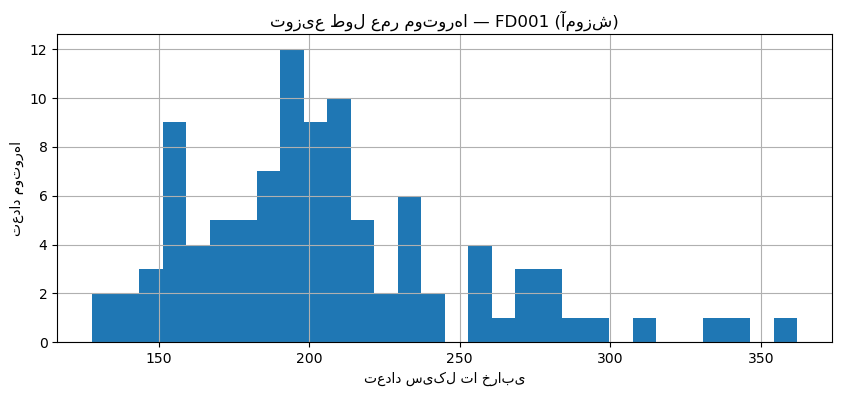

In [23]:
# --- توزیع طول توالی هر موتور ---
seq_lengths = train.groupby("engine_id")["cycle"].max()
print("آمار طول توالی موتورها (مجموعه‌ی آموزش):")
print(seq_lengths.describe())

seq_lengths.hist(bins=30)
plt.title(f"توزیع طول عمر موتورها — {FD} (آموزش)")
plt.xlabel("تعداد سیکل تا خرابی")
plt.ylabel("تعداد موتورها")
plt.show()


In [24]:
# --- بررسی مقادیر گمشده و غیرمتناهی ---
print("مقادیر گمشده در مجموعه‌ی آموزش:")
print(train.isna().sum()[train.isna().sum() > 0])

print("\nتعداد مقادیر غیرمتناهی در مجموعه‌ی آموزش:")
print(np.isinf(train.select_dtypes(include=[np.number])).sum().sum())

# --- بررسی کلید تکراری (engine_id, cycle) ---
dup_keys = train.duplicated(subset=["engine_id", "cycle"]).sum()
print(f"\nتعداد کلیدهای تکراری (engine_id, cycle): {dup_keys}")

# --- بررسی پیوستگی سیکل‌ها ---
def check_cycle_continuity(df):
    broken = []
    for eid, g in df.groupby("engine_id"):
        cycles = g["cycle"].sort_values().values
        expected = np.arange(1, len(cycles) + 1)
        if not np.array_equal(cycles, expected):
            broken.append(eid)
    return broken

broken_engines = check_cycle_continuity(train)
print(f"موتورهای دارای ناپیوستگی در سیکل: {broken_engines}")


مقادیر گمشده در مجموعه‌ی آموزش:
Series([], dtype: int64)

تعداد مقادیر غیرمتناهی در مجموعه‌ی آموزش:
0

تعداد کلیدهای تکراری (engine_id, cycle): 0
موتورهای دارای ناپیوستگی در سیکل: []


In [25]:
# --- بررسی سنسورهای تقریباً ثابت (فقط روی داده‌ی آموزش) ---
sensor_std = train[SENSOR_COLS].std()
near_constant = sensor_std[sensor_std < 1e-3].index.tolist()
print("سنسورهای تقریباً ثابت (انحراف معیار کمتر از ۰.۰۰۱) — روی مجموعه‌ی آموزش:")
print(sensor_std.sort_values())
print(f"\nسنسورهای کاندید حذف: {near_constant}")


سنسورهای تقریباً ثابت (انحراف معیار کمتر از ۰.۰۰۱) — روی مجموعه‌ی آموزش:
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.556432e-14
sensor_10    4.660829e-13
sensor_5     3.394700e-12
sensor_1     6.537152e-11
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

سنسورهای کاندید حذف: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


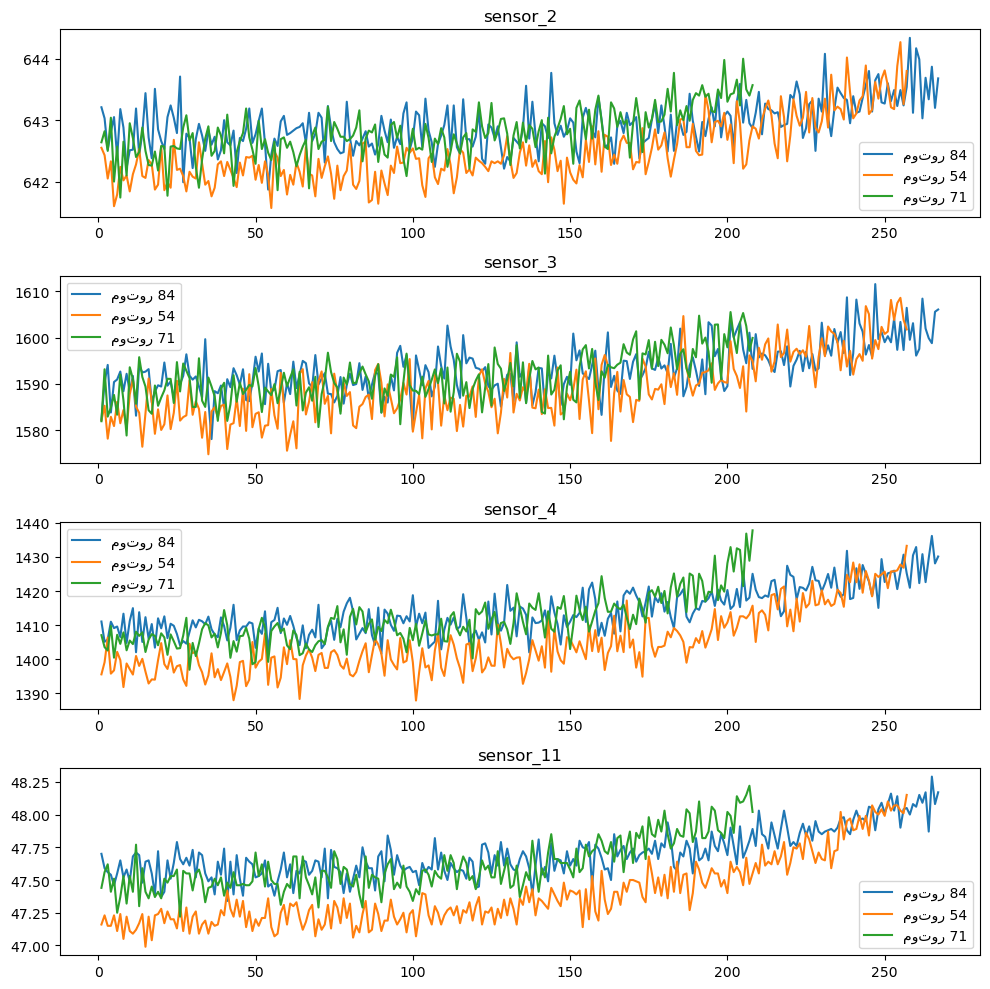

In [26]:
# --- مسیر تخریب چند موتور نمونه ---
sample_engines = train["engine_id"].drop_duplicates().sample(3, random_state=SEED).tolist()
sensors_to_plot = ["sensor_2", "sensor_3", "sensor_4", "sensor_11"]

fig, axes = plt.subplots(len(sensors_to_plot), 1, figsize=(10, 10), sharex=False)
for ax, sensor in zip(axes, sensors_to_plot):
    for eid in sample_engines:
        eng_data = train[train["engine_id"] == eid]
        ax.plot(eng_data["cycle"], eng_data[sensor], label=f"موتور {eid}")
    ax.set_title(sensor)
    ax.legend()
plt.tight_layout()
plt.show()


## گام صفر (تکمیل) — تقسیم بر اساس موتور (آموزش / اعتبارسنجی / آزمون)

- مجموعه‌ی `test_FD001.txt` همان مجموعه‌ی آزمون رسمی بنچمارک است و دست‌نخورده می‌ماند؛ فقط یک‌بار در انتها برای گزارش نهایی استفاده می‌شود.
- از بین ۱۰۰ موتور `train_FD001.txt`، ۸۰ موتور برای آموزش و ۲۰ موتور برای اعتبارسنجی جدا می‌شوند.
- این تقسیم **قبل از هرگونه فیچرسازی، مقیاس‌گذاری یا انتخاب فیچر** انجام می‌شود.


In [27]:
from sklearn.model_selection import train_test_split

VAL_FRACTION = 0.20

all_train_engine_ids = train["engine_id"].unique()

train_engine_ids, val_engine_ids = train_test_split(
    all_train_engine_ids,
    test_size=VAL_FRACTION,
    random_state=SEED,
)

print(f"تعداد کل موتورهای آموزش اولیه: {len(all_train_engine_ids)}")
print(f"موتورهای آموزش نهایی: {len(train_engine_ids)}")
print(f"موتورهای اعتبارسنجی: {len(val_engine_ids)}")

# --- بررسی عدم همپوشانی ---
assert set(train_engine_ids).isdisjoint(set(val_engine_ids)), "همپوشانی بین آموزش و اعتبارسنجی مجاز نیست!"

train_split = train[train["engine_id"].isin(train_engine_ids)].reset_index(drop=True)
val_split = train[train["engine_id"].isin(val_engine_ids)].reset_index(drop=True)
test_split = test.reset_index(drop=True)  # مجموعه‌ی آزمون رسمی، بدون تغییر

print(f"\nابعاد آموزش نهایی: {train_split.shape}")
print(f"ابعاد اعتبارسنجی: {val_split.shape}")
print(f"ابعاد آزمون: {test_split.shape}")


تعداد کل موتورهای آموزش اولیه: 100
موتورهای آموزش نهایی: 80
موتورهای اعتبارسنجی: 20

ابعاد آموزش نهایی: (16561, 27)
ابعاد اعتبارسنجی: (4070, 27)
ابعاد آزمون: (13096, 27)


In [28]:
# --- ذخیره‌ی شناسه‌های اسپلیت روی دیسک (برای ردیابی و جلوگیری از نشت داده در آینده) ---
import json as _json

split_ids = {
    "train_engine_ids": sorted(int(x) for x in train_engine_ids),
    "val_engine_ids": sorted(int(x) for x in val_engine_ids),
    "fd": FD,
    "seed": SEED,
}

with open(f"{ARTIFACTS_DIR}/split_ids_{FD}.json", "w", encoding="utf-8") as f:
    _json.dump(split_ids, f, indent=2, ensure_ascii=False)

print(f"شناسه‌های اسپلیت ذخیره شدند: {ARTIFACTS_DIR}/split_ids_{FD}.json")


شناسه‌های اسپلیت ذخیره شدند: ../artifacts/split_ids_FD001.json


## گام دو — مهندسی فیچر زمانی علّی

فیچرهای پنجره‌ای باید فقط از سیکل‌های t و قبل از آن استفاده کنند.
پنجره‌های میان‌محور یا نرمال‌سازی روی کل موتور، نشت داده محسوب می‌شود.

In [29]:
def add_rolling_features(df, sensor_cols, window=5):
    """
    ساخت فیچرهای پنجره‌ای علّی برای هر سنسور، به تفکیک هر موتور.
    فقط از سیکل‌های t و قبل از آن استفاده می‌شود.
    """
    df = df.sort_values(["engine_id", "cycle"]).copy()
    grouped = df.groupby("engine_id")[sensor_cols]

    roll_mean = grouped.transform(lambda s: s.rolling(window, min_periods=1).mean())
    roll_std = grouped.transform(lambda s: s.rolling(window, min_periods=1).std().fillna(0))
    roll_min = grouped.transform(lambda s: s.rolling(window, min_periods=1).min())
    roll_max = grouped.transform(lambda s: s.rolling(window, min_periods=1).max())

    roll_mean.columns = [f"{c}_roll_mean_w{window}" for c in sensor_cols]
    roll_std.columns = [f"{c}_roll_std_w{window}" for c in sensor_cols]
    roll_min.columns = [f"{c}_roll_min_w{window}" for c in sensor_cols]
    roll_max.columns = [f"{c}_roll_max_w{window}" for c in sensor_cols]

    diff1 = grouped.transform(lambda s: s.diff().fillna(0))
    diff1.columns = [f"{c}_diff1" for c in sensor_cols]

    def rolling_slope(s):
        def slope(x):
            if len(x) < 2:
                return 0.0
            idx = np.arange(len(x))
            return np.polyfit(idx, x, 1)[0]
        return s.rolling(window, min_periods=2).apply(slope, raw=True).fillna(0)

    roll_slope = grouped.transform(rolling_slope)
    roll_slope.columns = [f"{c}_roll_slope_w{window}" for c in sensor_cols]

    result = pd.concat([df, roll_mean, roll_std, roll_min, roll_max, diff1, roll_slope], axis=1)
    return result

In [30]:
def causality_test(feature_fn, base_df, sensor_cols, at_cycle_ratio=0.5, **kwargs):
    """
    اطمینان از این‌که تغییر سیکل‌های بعد از t، فیچر محاسبه‌شده در t را تغییر نمی‌دهد.
    """
    sample_engine = base_df["engine_id"].iloc[0]
    engine_data = base_df[base_df["engine_id"] == sample_engine].copy()
    cut = int(len(engine_data) * at_cycle_ratio)

    original = feature_fn(engine_data, sensor_cols, **kwargs)
    original_before_cut = original.iloc[:cut].reset_index(drop=True)

    tampered = engine_data.copy()
    tampered.loc[tampered.index[cut:], sensor_cols] = tampered.loc[tampered.index[cut:], sensor_cols] * 999
    tampered_features = feature_fn(tampered, sensor_cols, **kwargs)
    tampered_before_cut = tampered_features.iloc[:cut].reset_index(drop=True)

    feature_cols = [c for c in original.columns if c not in base_df.columns]
    diff = (original_before_cut[feature_cols] - tampered_before_cut[feature_cols]).abs().sum().sum()

    assert diff < 1e-6, f"نشت داده شناسایی شد! اختلاف: {diff}"
    print("تست علّی‌بودن با موفقیت پاس شد.")

In [31]:
causality_test(add_rolling_features, train_split, SENSOR_COLS, window=5)

تست علّی‌بودن با موفقیت پاس شد.


In [32]:
WINDOW = 5

train_feat = add_rolling_features(train_split, SENSOR_COLS, window=WINDOW)
val_feat = add_rolling_features(val_split, SENSOR_COLS, window=WINDOW)
test_feat = add_rolling_features(test_split, SENSOR_COLS, window=WINDOW)

print(f"ابعاد آموزش با فیچر: {train_feat.shape}")
print(f"ابعاد اعتبارسنجی با فیچر: {val_feat.shape}")
print(f"ابعاد آزمون با فیچر: {test_feat.shape}")

train_feat.head()

ابعاد آموزش با فیچر: (16561, 153)
ابعاد اعتبارسنجی با فیچر: (4070, 153)
ابعاد آزمون با فیچر: (13096, 153)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_7_roll_slope_w5,sensor_8_roll_slope_w5,sensor_9_roll_slope_w5,sensor_10_roll_slope_w5,sensor_11_roll_slope_w5,sensor_12_roll_slope_w5,sensor_13_roll_slope_w5,sensor_14_roll_slope_w5,sensor_15_roll_slope_w5,sensor_16_roll_slope_w5,sensor_17_roll_slope_w5,sensor_18_roll_slope_w5,sensor_19_roll_slope_w5,sensor_20_roll_slope_w5,sensor_21_roll_slope_w5
0,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,21.60,554.53,2388.01,9054.72,1.3,...,0.000,0.000,0.000,0.000000e+00,0.000,0.000,0.000,0.000,0.00000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000,0.00000
1,2,2,0.0043,-0.0003,100.0,518.67,641.82,1587.05,1393.13,14.62,21.61,554.77,2387.98,9051.31,1.3,...,0.240,-0.030,-3.410,-1.700163e-16,0.310,0.370,-0.080,-6.630,0.02620,-2.821982e-18,1.000000e+00,-2.380662e-13,-4.719521e-15,0.120,-0.05000
2,2,3,0.0018,0.0003,100.0,518.67,641.55,1588.32,1398.96,14.62,21.60,555.14,2388.04,9054.24,1.3,...,0.305,0.015,-0.240,-1.362769e-17,0.145,0.125,-0.035,1.430,-0.00515,4.775788e-19,-3.648559e-14,7.595739e-15,-8.148103e-15,0.085,-0.01675
3,2,4,0.0035,-0.0004,100.0,518.67,641.68,1584.15,1396.08,14.62,21.61,554.25,2387.98,9058.01,1.3,...,-0.047,-0.003,1.280,-3.210458e-17,0.049,0.036,-0.038,1.765,-0.00026,1.724513e-18,-1.000000e-01,6.276187e-14,8.439240e-15,0.062,0.01491
4,2,5,0.0005,0.0004,100.0,518.67,641.73,1579.03,1402.52,14.62,21.60,555.12,2388.03,9058.15,1.3,...,0.066,0.004,1.356,-1.881171e-16,0.050,-0.033,-0.029,0.725,-0.00225,-4.398249e-18,-3.000000e-01,-3.885742e-13,-1.068778e-14,0.055,0.00240


## گام سه — رگرسیون عمر مفید باقی‌مانده

مقدار هدف با سقف صدوبیست‌وپنج ساخته می‌شود تا از فیت‌شدن روی نویز در ابتدای عمر موتور جلوگیری شود.
سقف فقط بر اساس داده‌ی آموزش و اعتبارسنجی توجیه می‌شود، نه داده‌ی آزمون.

In [33]:
# --- حذف سنسورهای تقریباً ثابت و فیچرهای مشتق از آن‌ها ---
CONSTANT_SENSORS = ["sensor_1", "sensor_5", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]

drop_cols = [c for c in train_feat.columns if any(c.startswith(cs) for cs in CONSTANT_SENSORS)]
print(f"تعداد ستون‌های حذف‌شده: {len(drop_cols)}")

train_feat = train_feat.drop(columns=drop_cols)
val_feat = val_feat.drop(columns=drop_cols)
test_feat = test_feat.drop(columns=drop_cols)

# --- ساخت هدف سقف‌دار ---
RUL_CAP = 125

train_feat["RUL_capped"] = train_feat["RUL"].clip(upper=RUL_CAP)
val_feat["RUL_capped"] = val_feat["RUL"].clip(upper=RUL_CAP)
# مقدار سقف‌دار روی آزمون فقط برای مقایسه محاسبه می‌شود، نه برای تنظیم مدل
test_feat["RUL_capped"] = test_feat["RUL"].clip(upper=RUL_CAP)

print(f"ابعاد نهایی آموزش: {train_feat.shape}")

تعداد ستون‌های حذف‌شده: 84
ابعاد نهایی آموزش: (16561, 70)


In [34]:
NON_FEATURE_COLS = ["engine_id", "cycle", "RUL", "RUL_capped"]
FEATURE_COLS = [c for c in train_feat.columns if c not in NON_FEATURE_COLS]

X_train, y_train = train_feat[FEATURE_COLS], train_feat["RUL_capped"]
X_val, y_val = val_feat[FEATURE_COLS], val_feat["RUL_capped"]
X_test, y_test = test_feat[FEATURE_COLS], test_feat["RUL_capped"]
y_test_raw = test_feat["RUL"]  # برای مقایسه‌ی نهایی بدون سقف

print(f"تعداد فیچرها: {len(FEATURE_COLS)}")

تعداد فیچرها: 66


In [35]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "ریج": make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=SEED)),
    "ریج چندجمله‌ای درجه ۲": make_pipeline(
        StandardScaler(), PolynomialFeatures(degree=2, include_bias=False), Ridge(alpha=10.0, random_state=SEED)
    ),
    "جنگل تصادفی": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=SEED, n_jobs=-1),
    "گرادیان بوستینگ": GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=SEED),
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    preds = np.clip(preds, 0, None)  # RUL منفی بی‌معناست

    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)

    results.append({"مدل": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    predictions[name] = preds
    print(f"{name} — MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.3f}")

results_df = pd.DataFrame(results).sort_values("MAE")
results_df

ریج — MAE: 15.85 | RMSE: 20.04 | R2: 0.769
ریج چندجمله‌ای درجه ۲ — MAE: 15.05 | RMSE: 19.32 | R2: 0.786
جنگل تصادفی — MAE: 11.94 | RMSE: 16.72 | R2: 0.839
گرادیان بوستینگ — MAE: 12.21 | RMSE: 16.84 | R2: 0.837


,مدل,MAE,RMSE,R2
2,جنگل تصادفی,11.935605,16.720648,0.839340
3,گرادیان بوستینگ,12.210696,16.838600,0.837065
1,ریج چندجمله‌ای درجه ۲,15.045357,19.316976,0.785573
0,ریج,15.848872,20.039562,0.769231


## گام سه (ادامه) — تحلیل خطا و ردهای پیش‌بینی

نتایج به تفکیک ناحیه‌ی عمر موتور و به‌صورت نمودار باقیمانده بررسی می‌شود.

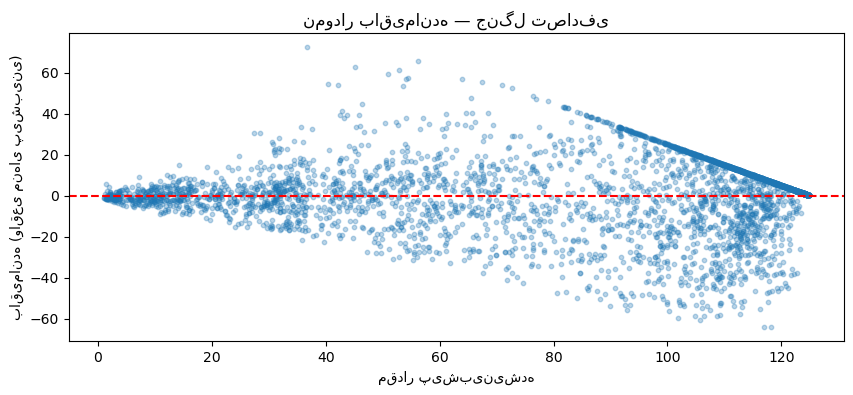

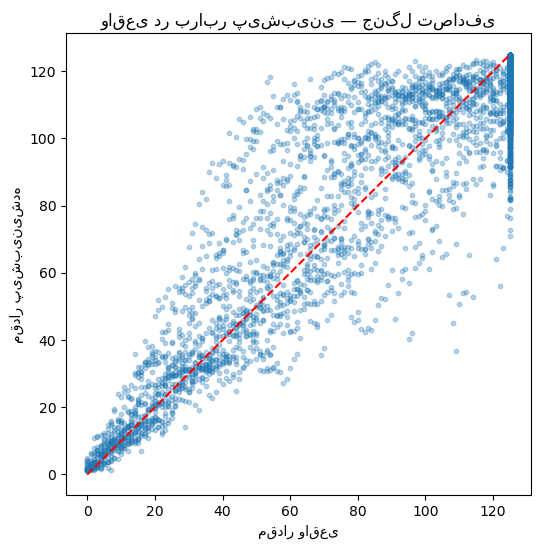

In [36]:
BEST_MODEL_NAME = "جنگل تصادفی"
best_model = models[BEST_MODEL_NAME]
val_preds = predictions[BEST_MODEL_NAME]

residuals = y_val.values - val_preds

plt.figure(figsize=(10, 4))
plt.scatter(val_preds, residuals, alpha=0.3, s=10)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("مقدار پیش‌بینی‌شده")
plt.ylabel("باقیمانده (واقعی منهای پیش‌بینی)")
plt.title(f"نمودار باقیمانده — {BEST_MODEL_NAME}")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_val, val_preds, alpha=0.3, s=10)
plt.plot([0, RUL_CAP], [0, RUL_CAP], color="red", linestyle="--")
plt.xlabel("مقدار واقعی")
plt.ylabel("مقدار پیش‌بینی‌شده")
plt.title(f"واقعی در برابر پیش‌بینی — {BEST_MODEL_NAME}")
plt.show()

In [37]:
def life_region(rul_value, cap=RUL_CAP):
    if rul_value > cap * 0.7:
        return "عمر اولیه"
    elif rul_value > cap * 0.3:
        return "عمر میانی"
    else:
        return "نزدیک به خرابی"

val_eval = val_feat[["engine_id", "cycle"]].copy()
val_eval["y_true"] = y_val.values
val_eval["y_pred"] = val_preds
val_eval["region"] = val_eval["y_true"].apply(life_region)

region_report = val_eval.groupby("region").apply(
    lambda g: pd.Series({
        "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "تعداد نمونه": len(g),
    })
).reset_index()

region_report

C:\Users\VivoBook\AppData\Local\Temp\ipykernel_21332\2091151525.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  region_report = val_eval.groupby("region").apply(


,region,MAE,RMSE,تعداد نمونه
0,عمر اولیه,10.657273,14.451549,2310.0
1,عمر میانی,18.915251,23.880914,1000.0
2,نزدیک به خرابی,6.637316,10.585218,760.0


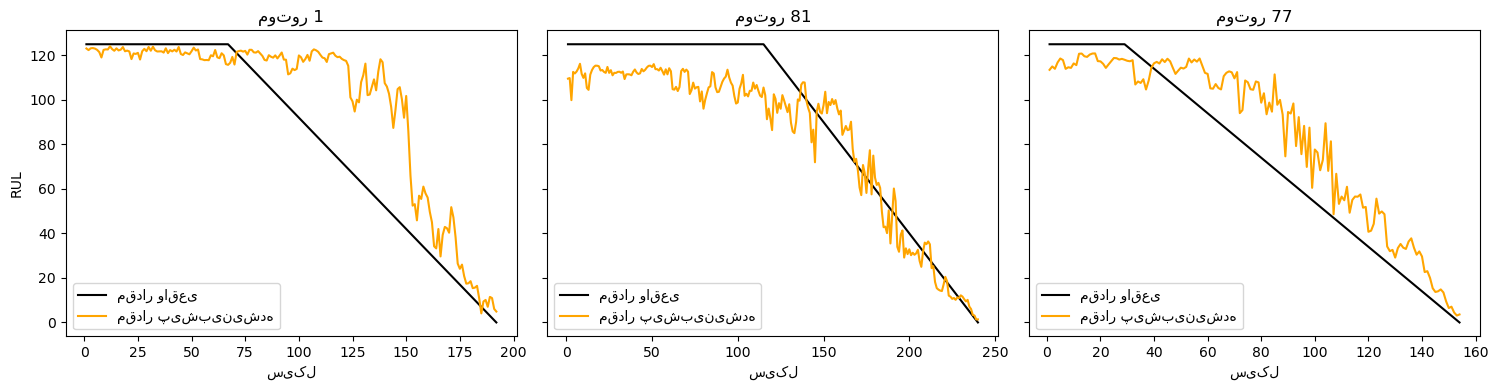

In [38]:
sample_val_engines = val_feat["engine_id"].drop_duplicates().sample(3, random_state=SEED).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, eid in zip(axes, sample_val_engines):
    eng_mask = val_eval["engine_id"] == eid
    eng_data = val_eval[eng_mask].sort_values("cycle")
    ax.plot(eng_data["cycle"], eng_data["y_true"], label="مقدار واقعی", color="black")
    ax.plot(eng_data["cycle"], eng_data["y_pred"], label="مقدار پیش‌بینی‌شده", color="orange")
    ax.set_title(f"موتور {eid}")
    ax.set_xlabel("سیکل")
    ax.legend()
axes[0].set_ylabel("RUL")
plt.tight_layout()
plt.show()

## گام سه (پایانی) — امتیاز نامتقارن نگهداری

قرارداد علامت: خطا برابر است با پیش‌بینی منهای واقعی.
خطای مثبت یعنی پیش‌بینی بیش‌ازحد خوش‌بینانه و دیرهنگام است و جریمه‌ی سنگین‌تری می‌گیرد.
خطای منفی یعنی پیش‌بینی محتاطانه و زودهنگام است و جریمه‌ی ملایم‌تری می‌گیرد.
این قرارداد با یک مثال دستی پیش از استفاده‌ی واقعی تأیید می‌شود.

In [39]:
def phm_asymmetric_score(y_true, y_pred, a_early=13, a_late=10):
    """
    امتیاز نمایی نامتقارن PHM/NASA.
    d = پیش‌بینی - واقعی
    d < 0 (پیش‌بینی زودهنگام): جریمه‌ی ملایم‌تر با ثابت a_early
    d > 0 (پیش‌بینی دیرهنگام): جریمه‌ی شدیدتر با ثابت a_late
    """
    d = np.asarray(y_pred) - np.asarray(y_true)
    score = np.where(
        d < 0,
        np.exp(-d / a_early) - 1,
        np.exp(d / a_late) - 1,
    )
    return score.sum(), score


# --- مثال دستی برای تأیید قرارداد علامت ---
# دو سناریو با اندازه‌ی خطای یکسان (۱۰ سیکل)، ولی جهت مخالف:
true_val = 50
early_pred = 40   # پیش‌بینی زودهنگام (محتاطانه)، d = -10
late_pred = 60    # پیش‌بینی دیرهنگام (خوش‌بینانه، خطرناک)، d = +10

early_total, _ = phm_asymmetric_score(np.array([true_val]), np.array([early_pred]))
late_total, _ = phm_asymmetric_score(np.array([true_val]), np.array([late_pred]))

print(f"جریمه‌ی پیش‌بینی زودهنگام (خطای ۱۰-): {early_total:.3f}")
print(f"جریمه‌ی پیش‌بینی دیرهنگام (خطای ۱۰+):  {late_total:.3f}")

assert late_total > early_total, "قرارداد علامت اشتباه است! پیش‌بینی دیرهنگام باید جریمه‌ی بیشتری بگیرد."
print("قرارداد علامت تأیید شد: پیش‌بینی دیرهنگام جریمه‌ی سنگین‌تری می‌گیرد.")

جریمه‌ی پیش‌بینی زودهنگام (خطای ۱۰-): 1.158
جریمه‌ی پیش‌بینی دیرهنگام (خطای ۱۰+):  1.718
قرارداد علامت تأیید شد: پیش‌بینی دیرهنگام جریمه‌ی سنگین‌تری می‌گیرد.


In [40]:
total_score, per_sample_score = phm_asymmetric_score(y_val.values, val_preds)

print(f"مجموع امتیاز نامتقارن روی مجموعه‌ی اعتبارسنجی: {total_score:.2f}")
print(f"میانگین امتیاز به‌ازای هر نمونه: {total_score / len(y_val):.3f}")

# --- توزیع جریمه‌ها به تفکیک زودهنگام/دیرهنگام ---
d = val_preds - y_val.values
n_late = (d > 0).sum()
n_early = (d < 0).sum()
print(f"\nتعداد پیش‌بینی‌های دیرهنگام (خطرناک): {n_late}")
print(f"تعداد پیش‌بینی‌های زودهنگام (محتاطانه): {n_early}")

مجموع امتیاز نامتقارن روی مجموعه‌ی اعتبارسنجی: 30714.26
میانگین امتیاز به‌ازای هر نمونه: 7.547

تعداد پیش‌بینی‌های دیرهنگام (خطرناک): 1518
تعداد پیش‌بینی‌های زودهنگام (محتاطانه): 2552


## گام چهار — کلاس‌بندی افق خرابی

برای هر افق ده، بیست و سی سیکل، یک برچسب دودویی جداگانه ساخته می‌شود.
رگرسیون لجستیک به عنوان مدل شفاف پایه و یک کلاس‌بند غیرخطی برای مقایسه استفاده می‌شود.

In [41]:
HORIZONS = [10, 20, 30]

for h in HORIZONS:
    train_feat[f"fail_within_{h}"] = (train_feat["RUL"] <= h).astype(int)
    val_feat[f"fail_within_{h}"] = (val_feat["RUL"] <= h).astype(int)
    test_feat[f"fail_within_{h}"] = (test_feat["RUL"] <= h).astype(int)

for h in HORIZONS:
    rate = train_feat[f"fail_within_{h}"].mean()
    print(f"افق {h} سیکل — نسبت نمونه‌های مثبت در آموزش: {rate:.3f}")

افق 10 سیکل — نسبت نمونه‌های مثبت در آموزش: 0.053
افق 20 سیکل — نسبت نمونه‌های مثبت در آموزش: 0.101
افق 30 سیکل — نسبت نمونه‌های مثبت در آموزش: 0.150


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, brier_score_loss,
    precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.calibration import calibration_curve

clf_results = []
clf_predictions = {}

for h in HORIZONS:
    y_train_h = train_feat[f"fail_within_{h}"]
    y_val_h = val_feat[f"fail_within_{h}"]

    clf_models = {
        "رگرسیون لجستیک": make_pipeline(
            StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
        ),
        "جنگل تصادفی": RandomForestClassifier(
            n_estimators=200, max_depth=10, class_weight="balanced", random_state=SEED, n_jobs=-1
        ),
    }

    for name, model in clf_models.items():
        model.fit(X_train, y_train_h)
        probs = model.predict_proba(X_val)[:, 1]

        pr_auc = average_precision_score(y_val_h, probs)
        brier = brier_score_loss(y_val_h, probs)

        clf_results.append({"افق": h, "مدل": name, "PR-AUC": pr_auc, "Brier": brier})
        clf_predictions[(h, name)] = probs

        print(f"افق {h} — {name} — PR-AUC: {pr_auc:.3f} | Brier: {brier:.3f}")

clf_results_df = pd.DataFrame(clf_results)
clf_results_df

افق 10 — رگرسیون لجستیک — PR-AUC: 0.937 | Brier: 0.025
افق 10 — جنگل تصادفی — PR-AUC: 0.913 | Brier: 0.017
افق 20 — رگرسیون لجستیک — PR-AUC: 0.953 | Brier: 0.036
افق 20 — جنگل تصادفی — PR-AUC: 0.947 | Brier: 0.023
افق 30 — رگرسیون لجستیک — PR-AUC: 0.963 | Brier: 0.045
افق 30 — جنگل تصادفی — PR-AUC: 0.953 | Brier: 0.032


,افق,مدل,PR-AUC,Brier
0,10,رگرسیون لجستیک,0.936784,0.025030
1,10,جنگل تصادفی,0.913089,0.016516
2,20,رگرسیون لجستیک,0.953100,0.035533
3,20,جنگل تصادفی,0.947288,0.023314
4,30,رگرسیون لجستیک,0.962973,0.045313
5,30,جنگل تصادفی,0.953381,0.032050


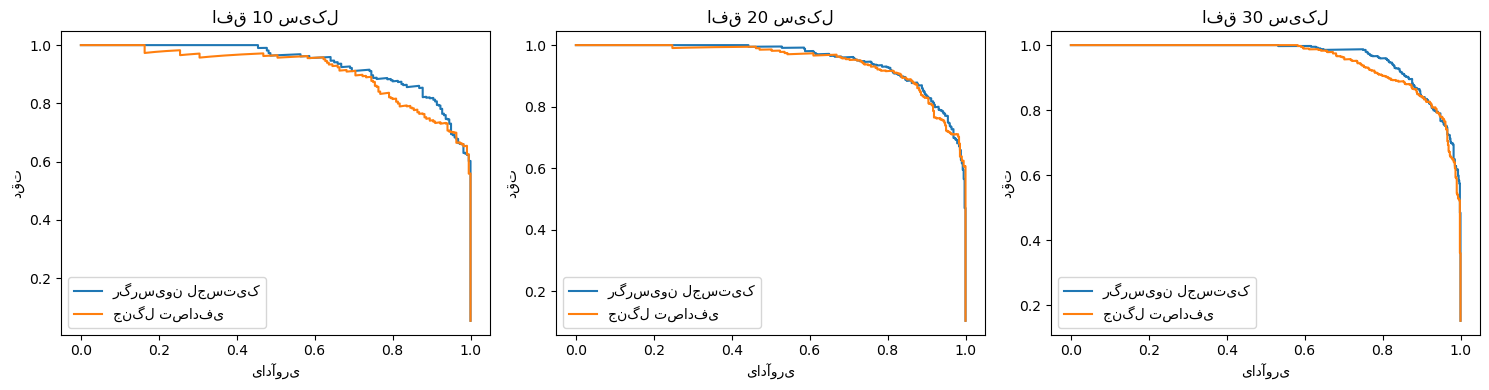

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, h in zip(axes, HORIZONS):
    y_val_h = val_feat[f"fail_within_{h}"]
    for name in ["رگرسیون لجستیک", "جنگل تصادفی"]:
        probs = clf_predictions[(h, name)]
        precision, recall, _ = precision_recall_curve(y_val_h, probs)
        ax.plot(recall, precision, label=name)
    ax.set_title(f"افق {h} سیکل")
    ax.set_xlabel("یادآوری")
    ax.set_ylabel("دقت")
    ax.legend()

plt.tight_layout()
plt.show()

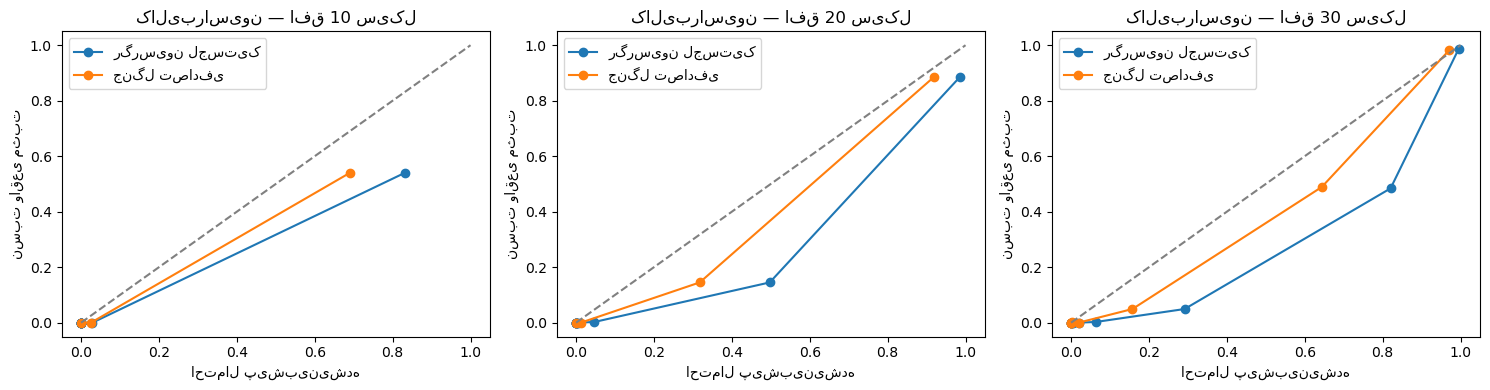

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, h in zip(axes, HORIZONS):
    y_val_h = val_feat[f"fail_within_{h}"]
    for name in ["رگرسیون لجستیک", "جنگل تصادفی"]:
        probs = clf_predictions[(h, name)]
        frac_pos, mean_pred = calibration_curve(y_val_h, probs, n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac_pos, marker="o", label=name)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_title(f"کالیبراسیون — افق {h} سیکل")
    ax.set_xlabel("احتمال پیش‌بینی‌شده")
    ax.set_ylabel("نسبت واقعی مثبت")
    ax.legend()

plt.tight_layout()
plt.show()

## گام چهار (ادامه) — انتخاب آستانه بر اساس هزینه

هزینه‌ی هشدار ازدست‌رفته بسیار بیشتر از هزینه‌ی هشدار اشتباه در نظر گرفته می‌شود.
آستانه‌ی هر افق به‌صورت جداگانه و فقط روی مجموعه‌ی اعتبارسنجی انتخاب می‌شود.

In [45]:
def find_optimal_threshold(y_true, probs, cost_fn=5, cost_fp=1):
    """
    جست‌وجوی آستانه‌ای که مجموع هزینه را کمینه می‌کند.
    cost_fn: هزینه‌ی هشدار ازدست‌رفته (منفی کاذب) — سنگین‌تر
    cost_fp: هزینه‌ی هشدار اشتباه (مثبت کاذب) — سبک‌تر
    """
    thresholds = np.linspace(0.01, 0.99, 99)
    best_threshold, best_cost = 0.5, np.inf

    for t in thresholds:
        preds = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
        cost = cost_fn * fn + cost_fp * fp
        if cost < best_cost:
            best_cost = cost
            best_threshold = t

    return best_threshold, best_cost


BEST_CLF_NAME = "رگرسیون لجستیک"  # بر اساس PR-AUC برتر
threshold_results = []

for h in HORIZONS:
    y_val_h = val_feat[f"fail_within_{h}"]
    probs = clf_predictions[(h, BEST_CLF_NAME)]

    thr, cost = find_optimal_threshold(y_val_h, probs, cost_fn=5, cost_fp=1)
    preds_at_thr = (probs >= thr).astype(int)

    precision = precision_score(y_val_h, preds_at_thr, zero_division=0)
    recall = recall_score(y_val_h, preds_at_thr, zero_division=0)
    f1 = f1_score(y_val_h, preds_at_thr, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_val_h, preds_at_thr, labels=[0, 1]).ravel()

    threshold_results.append({
        "افق": h, "آستانه": thr, "دقت": precision, "یادآوری": recall, "F1": f1,
        "مثبت‌کاذب": fp, "منفی‌کاذب": fn, "هزینه": cost,
    })
    print(f"افق {h} — آستانه‌ی بهینه: {thr:.2f} | دقت: {precision:.3f} | یادآوری: {recall:.3f} | F1: {f1:.3f}")

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

افق 10 — آستانه‌ی بهینه: 0.86 | دقت: 0.746 | یادآوری: 0.945 | F1: 0.834
افق 20 — آستانه‌ی بهینه: 0.70 | دقت: 0.770 | یادآوری: 0.955 | F1: 0.852
افق 30 — آستانه‌ی بهینه: 0.59 | دقت: 0.752 | یادآوری: 0.965 | F1: 0.845


,افق,آستانه,دقت,یادآوری,F1,مثبت‌کاذب,منفی‌کاذب,هزینه
0,10,0.86,0.745520,0.945455,0.833667,71,12,131
1,20,0.70,0.769674,0.954762,0.852285,120,19,215
2,30,0.59,0.752201,0.964516,0.845230,197,22,307


## گام چهار (تکمیل نهایی) — ماتریس درهم‌ریختگی

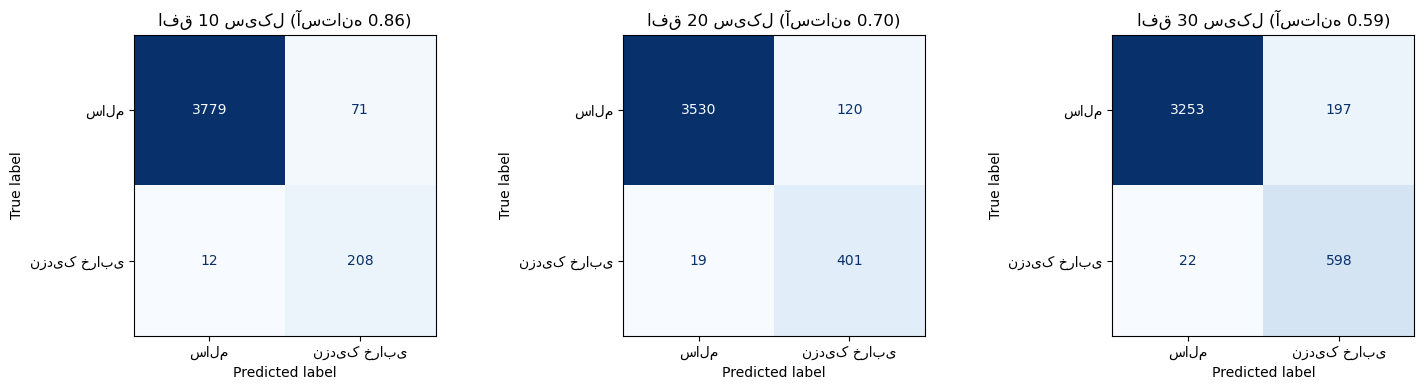

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, h in zip(axes, HORIZONS):
    y_val_h = val_feat[f"fail_within_{h}"]
    probs = clf_predictions[(h, BEST_CLF_NAME)]
    thr = threshold_results_df.loc[threshold_results_df["افق"] == h, "آستانه"].values[0]
    preds_at_thr = (probs >= thr).astype(int)

    cm = confusion_matrix(y_val_h, preds_at_thr, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["سالم", "نزدیک خرابی"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"افق {h} سیکل (آستانه {thr:.2f})")

plt.tight_layout()
plt.show()

## گام پنج — تشخیص ناهنجاری بدون نظارت

ناحیه‌ی سالم به عنوان سی درصد اول عمر هر موتور در مجموعه‌ی آموزش تعریف می‌شود.
هیچ برچسب خرابی یا مجاورت خرابی در مجموعه‌ی آزمون برای فیت مدل‌ها استفاده نمی‌شود.

In [47]:
HEALTHY_FRACTION = 0.30

# --- شناسایی سیکل‌های سالم بر اساس نسبت طول عمر هر موتور ---
train_max_cycle = train_feat.groupby("engine_id")["cycle"].transform("max")
healthy_mask = train_feat["cycle"] <= (train_max_cycle * HEALTHY_FRACTION)

healthy_data = train_feat[healthy_mask]
print(f"تعداد ردیف‌های سالم برای فیت مدل‌ها: {healthy_data.shape[0]} از {train_feat.shape[0]}")

# --- مقیاس‌گذاری فقط بر اساس ناحیه‌ی سالم ---
anomaly_scaler = StandardScaler()
X_healthy_scaled = anomaly_scaler.fit_transform(healthy_data[FEATURE_COLS])

X_train_scaled = anomaly_scaler.transform(X_train)
X_val_scaled = anomaly_scaler.transform(X_val)
X_test_scaled = anomaly_scaler.transform(X_test)

تعداد ردیف‌های سالم برای فیت مدل‌ها: 4931 از 16561


In [48]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200, contamination=0.05, random_state=SEED, n_jobs=-1
)
iso_forest.fit(X_healthy_scaled)

# --- علامت را طوری نرمال می‌کنیم که مقدار بزرگ‌تر یعنی ناهنجارتر ---
iso_scores_val = -iso_forest.score_samples(X_val_scaled)
iso_scores_test = -iso_forest.score_samples(X_test_scaled)

print(f"دامنه‌ی امتیاز جنگل انزوا (اعتبارسنجی): {iso_scores_val.min():.3f} تا {iso_scores_val.max():.3f}")

دامنه‌ی امتیاز جنگل انزوا (اعتبارسنجی): 0.374 تا 0.617


In [49]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=35, novelty=True, contamination=0.05)
lof.fit(X_healthy_scaled)

lof_scores_val = -lof.score_samples(X_val_scaled)
lof_scores_test = -lof.score_samples(X_test_scaled)

print(f"دامنه‌ی امتیاز عامل ناهنجاری محلی (اعتبارسنجی): {lof_scores_val.min():.3f} تا {lof_scores_val.max():.3f}")

دامنه‌ی امتیاز عامل ناهنجاری محلی (اعتبارسنجی): 0.974 تا 4.609


In [50]:
from sklearn.svm import OneClassSVM

# --- به دلیل هزینه‌ی محاسباتی، روی زیرنمونه‌ای از داده‌ی سالم فیت می‌شود ---
subsample_size = min(2000, len(X_healthy_scaled))
rng = np.random.RandomState(SEED)
subsample_idx = rng.choice(len(X_healthy_scaled), subsample_size, replace=False)

oc_svm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
oc_svm.fit(X_healthy_scaled[subsample_idx])

ocsvm_scores_val = -oc_svm.decision_function(X_val_scaled)
ocsvm_scores_test = -oc_svm.decision_function(X_test_scaled)

print(f"دامنه‌ی امتیاز تک‌کلاسه SVM (اعتبارسنجی): {ocsvm_scores_val.min():.3f} تا {ocsvm_scores_val.max():.3f}")

دامنه‌ی امتیاز تک‌کلاسه SVM (اعتبارسنجی): -5.593 تا 4.731


In [51]:
from sklearn.decomposition import PCA

# --- انتخاب تعداد مؤلفه بر اساس نسبت واریانس توضیح‌داده‌شده روی داده‌ی سالم ---
pca_full = PCA(random_state=SEED)
pca_full.fit(X_healthy_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cum_var >= 0.95) + 1
print(f"تعداد مؤلفه‌های انتخاب‌شده برای پوشش نود‌وپنج درصد واریانس: {n_components}")

pca = PCA(n_components=n_components, random_state=SEED)
pca.fit(X_healthy_scaled)


def pca_reconstruction_error(X_scaled, pca_model):
    X_transformed = pca_model.transform(X_scaled)
    X_reconstructed = pca_model.inverse_transform(X_transformed)
    return np.sum((X_scaled - X_reconstructed) ** 2, axis=1)


pca_scores_val = pca_reconstruction_error(X_val_scaled, pca)
pca_scores_test = pca_reconstruction_error(X_test_scaled, pca)

print(f"دامنه‌ی امتیاز بازسازی PCA (اعتبارسنجی): {pca_scores_val.min():.3f} تا {pca_scores_val.max():.3f}")

تعداد مؤلفه‌های انتخاب‌شده برای پوشش نود‌وپنج درصد واریانس: 34
دامنه‌ی امتیاز بازسازی PCA (اعتبارسنجی): 0.304 تا 81.489


In [52]:
from scipy.stats import rankdata

anomaly_scores_val = {
    "جنگل انزوا": iso_scores_val,
    "عامل ناهنجاری محلی": lof_scores_val,
    "تک‌کلاسه SVM": ocsvm_scores_val,
    "بازسازی PCA": pca_scores_val,
}

# --- چون مقیاس خام هر روش متفاوت است، به درصدک تبدیل می‌کنیم ---
anomaly_percentiles_val = {
    name: rankdata(scores) / len(scores) * 100
    for name, scores in anomaly_scores_val.items()
}

percentile_df = pd.DataFrame(anomaly_percentiles_val)
percentile_df["RUL"] = val_feat["RUL"].values

# --- همبستگی درصدک ناهنجاری با نزدیکی به خرابی (RUL کم‌تر یعنی نزدیک‌تر) ---
correlation_with_rul = percentile_df.corr()["RUL"].drop("RUL")
print("همبستگی درصدک ناهنجاری هر روش با RUL (منفی یعنی نزدیک خرابی همراه با ناهنجاری بیشتر):")
print(correlation_with_rul.sort_values())

همبستگی درصدک ناهنجاری هر روش با RUL (منفی یعنی نزدیک خرابی همراه با ناهنجاری بیشتر):
عامل ناهنجاری محلی   -0.666908
تک‌کلاسه SVM         -0.654410
جنگل انزوا           -0.581772
بازسازی PCA          -0.084243
Name: RUL, dtype: float64


## گام پنج (ادامه) — مسیر امتیاز هم‌تراز با سیکل تا خرابی

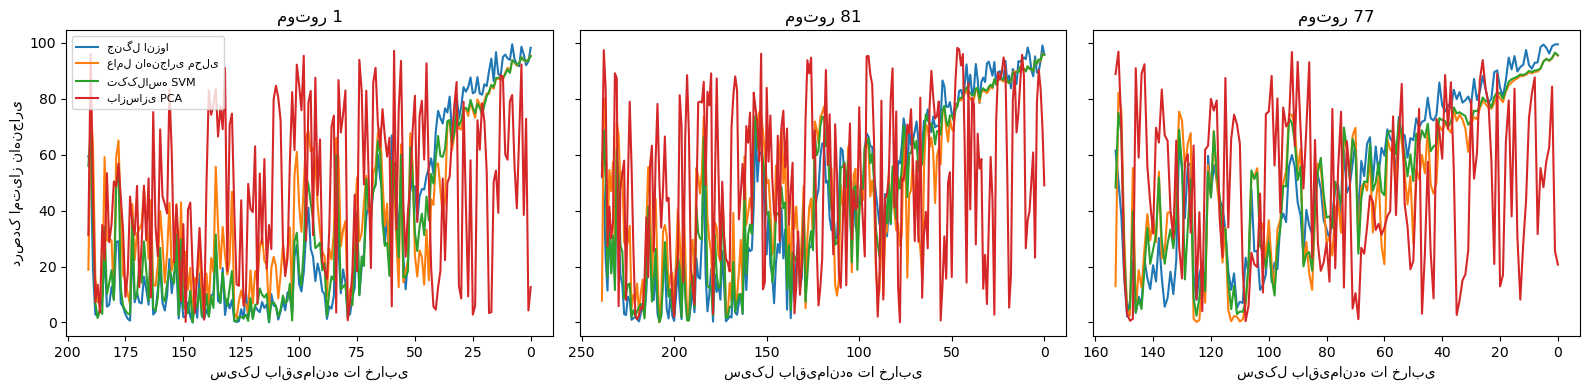

In [53]:
val_eval_anomaly = val_feat[["engine_id", "cycle", "RUL"]].copy()
for name, scores in anomaly_percentiles_val.items():
    val_eval_anomaly[name] = scores

sample_val_engines_anomaly = val_feat["engine_id"].drop_duplicates().sample(3, random_state=SEED).tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, eid in zip(axes, sample_val_engines_anomaly):
    eng_data = val_eval_anomaly[val_eval_anomaly["engine_id"] == eid].sort_values("cycle")
    cycles_to_failure = eng_data["RUL"]  # هر چه کمتر، نزدیک‌تر به خرابی
    for name in anomaly_percentiles_val.keys():
        ax.plot(cycles_to_failure, eng_data[name], label=name)
    ax.invert_xaxis()  # سمت راست نمودار یعنی نزدیک خرابی
    ax.set_title(f"موتور {eid}")
    ax.set_xlabel("سیکل باقیمانده تا خرابی")
axes[0].set_ylabel("درصدک امتیاز ناهنجاری")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## گام شش — تحلیل زمان هشدار و هزینه‌ی نامتقارن

امتیاز ناهنجاری نهایی میانگین سه روش قابل‌اعتماد است.
یک هشدار پایدار نیازمند حداقل سه هشدار از پنج سیکل اخیر است.
زمان هشدار به عنوان فاصله‌ی سیکل خرابی تا اولین هشدار پایدار تعریف می‌شود.

In [54]:
ALERT_PERCENTILE = 90
M_ALERTS = 3   # حداقل تعداد هشدار
N_WINDOW = 5   # در این تعداد سیکل اخیر

# --- امتیاز نهایی: میانگین سه روش قابل‌اعتماد ---
val_eval_anomaly["امتیاز_نهایی"] = val_eval_anomaly[
    ["جنگل انزوا", "عامل ناهنجاری محلی", "تک‌کلاسه SVM"]
].mean(axis=1)

alert_threshold = np.percentile(val_eval_anomaly["امتیاز_نهایی"], ALERT_PERCENTILE)
print(f"آستانه‌ی هشدار (درصدک {ALERT_PERCENTILE}): {alert_threshold:.2f}")

val_eval_anomaly["هشدار_لحظه‌ای"] = (val_eval_anomaly["امتیاز_نهایی"] >= alert_threshold).astype(int)


def find_first_persistent_alert(engine_df, m=M_ALERTS, n=N_WINDOW):
    """
    اولین سیکلی که در آن، حداقل m هشدار از n سیکل اخیر رخ داده باشد را برمی‌گرداند.
    اگر چنین سیکلی وجود نداشته باشد، None برمی‌گرداند (یعنی هشدار ازدست‌رفته).
    """
    engine_df = engine_df.sort_values("cycle")
    alerts = engine_df["هشدار_لحظه‌ای"].values
    cycles = engine_df["cycle"].values

    for i in range(len(alerts)):
        window_start = max(0, i - n + 1)
        window = alerts[window_start:i + 1]
        if window.sum() >= m:
            return cycles[i]
    return None

آستانه‌ی هشدار (درصدک 90): 89.91


In [55]:
lead_time_records = []

for eid, eng_df in val_eval_anomaly.groupby("engine_id"):
    failure_cycle = eng_df["cycle"].max()  # آخرین سیکل مشاهده‌شده در اعتبارسنجی (تقریب سیکل خرابی)
    first_alert_cycle = find_first_persistent_alert(eng_df)

    if first_alert_cycle is None:
        lead_time_records.append({
            "engine_id": eid, "سیکل_خرابی": failure_cycle,
            "اولین_هشدار_پایدار": None, "زمان_هشدار": None, "ازدست‌رفته": True,
        })
    else:
        lead_time = failure_cycle - first_alert_cycle
        lead_time_records.append({
            "engine_id": eid, "سیکل_خرابی": failure_cycle,
            "اولین_هشدار_پایدار": first_alert_cycle, "زمان_هشدار": lead_time, "ازدست‌رفته": False,
        })

lead_time_df = pd.DataFrame(lead_time_records)
n_missed = lead_time_df["ازدست‌رفته"].sum()
print(f"تعداد موتورهای بدون هشدار پایدار (ازدست‌رفته): {n_missed} از {len(lead_time_df)}")
print(f"\nآمار زمان هشدار (فقط موتورهای دارای هشدار):")
print(lead_time_df.loc[~lead_time_df["ازدست‌رفته"], "زمان_هشدار"].describe())

تعداد موتورهای بدون هشدار پایدار (ازدست‌رفته): 0 از 20

آمار زمان هشدار (فقط موتورهای دارای هشدار):
count    20.000000
mean     17.450000
std       8.268361
min       4.000000
25%       9.750000
50%      16.000000
75%      25.000000
max      31.000000
Name: زمان_هشدار, dtype: float64


## گام شش (ادامه) — هزینه‌ی نامتقارن

افق عملیاتی مرجع بیست سیکل در نظر گرفته می‌شود.
هزینه‌ی خرابی ازدست‌رفته از تأخیر دیرهنگام سنگین‌تر است و هزینه‌ی تأخیر دیرهنگام از بار زودهنگام سنگین‌تر است.

In [56]:
H_REFERENCE = 20  # افق عملیاتی هدف

lead_time_df["تأخیر_دیرهنگام"] = lead_time_df["زمان_هشدار"].apply(
    lambda l: max(0, H_REFERENCE - l) if pd.notna(l) else np.nan
)
lead_time_df["بار_زودهنگام"] = lead_time_df["زمان_هشدار"].apply(
    lambda l: max(0, l - H_REFERENCE) if pd.notna(l) else np.nan
)

# --- ضرایب هزینه: خرابی ازدست‌رفته سنگین‌ترین، تأخیر دیرهنگام میانی، بار زودهنگام سبک‌ترین ---
C_MISS = 100
C_LATE = 5
C_EARLY = 1

def compute_engine_cost(row):
    if row["ازدست‌رفته"]:
        return C_MISS
    return C_LATE * row["تأخیر_دیرهنگام"] + C_EARLY * row["بار_زودهنگام"]

lead_time_df["هزینه"] = lead_time_df.apply(compute_engine_cost, axis=1)

total_cost = lead_time_df["هزینه"].sum()
avg_cost = lead_time_df["هزینه"].mean()

print(f"مجموع هزینه روی مجموعه‌ی اعتبارسنجی: {total_cost:.1f}")
print(f"میانگین هزینه به‌ازای هر موتور: {avg_cost:.2f}")
print(f"\nمجموع تأخیر دیرهنگام: {lead_time_df['تأخیر_دیرهنگام'].sum():.1f}")
print(f"مجموع بار زودهنگام: {lead_time_df['بار_زودهنگام'].sum():.1f}")
print(f"تعداد خرابی‌های ازدست‌رفته: {n_missed}")

lead_time_df.sort_values("هزینه", ascending=False)

مجموع هزینه روی مجموعه‌ی اعتبارسنجی: 555.0
میانگین هزینه به‌ازای هر موتور: 27.75

مجموع تأخیر دیرهنگام: 101.0
مجموع بار زودهنگام: 50.0
تعداد خرابی‌های ازدست‌رفته: 0


,engine_id,سیکل_خرابی,اولین_هشدار_پایدار,زمان_هشدار,ازدست‌رفته,تأخیر_دیرهنگام,بار_زودهنگام,هزینه
14,74,166,162,4,False,16,0,80
15,77,154,146,8,False,12,0,60
0,1,192,183,9,False,11,0,55
6,31,234,225,9,False,11,0,55
11,46,256,247,9,False,11,0,55
19,91,135,125,10,False,10,0,50
5,23,168,157,11,False,9,0,45
17,81,240,228,12,False,8,0,40
16,78,231,216,15,False,5,0,25
10,45,158,143,15,False,5,0,25


## گام هفت — عدم قطعیت و اطمینان

بازه‌ی پیش‌بینی RUL با روش کانفورمال شکافته‌شده ساخته می‌شود.
پوشش تجربی و پهنای میانگین روی مجموعه‌ی آزمون گزارش می‌شود.

In [57]:
# --- کانفورمال شکافته: از مجموعه‌ی اعتبارسنجی برای کالیبراسیون خطا استفاده می‌شود ---
ALPHA = 0.10  # برای پوشش نوددرصدی

val_preds_best = best_model.predict(X_val)
val_preds_best = np.clip(val_preds_best, 0, None)
nonconformity_scores = np.abs(y_val.values - val_preds_best)

q_level = np.ceil((len(nonconformity_scores) + 1) * (1 - ALPHA)) / len(nonconformity_scores)
q_level = min(q_level, 1.0)
conformal_margin = np.quantile(nonconformity_scores, q_level)

print(f"حاشیه‌ی کانفورمال (برای پوشش {(1 - ALPHA) * 100:.0f} درصدی): {conformal_margin:.2f}")

# --- ساخت بازه روی مجموعه‌ی آزمون ---
test_preds_best = best_model.predict(X_test)
test_preds_best = np.clip(test_preds_best, 0, None)

test_lower = np.clip(test_preds_best - conformal_margin, 0, None)
test_upper = test_preds_best + conformal_margin

# --- پوشش تجربی و پهنای میانگین ---
y_test_capped = test_feat["RUL_capped"]
empirical_coverage = ((y_test_capped >= test_lower) & (y_test_capped <= test_upper)).mean()
avg_width = (test_upper - test_lower).mean()

print(f"پوشش تجربی روی آزمون: {empirical_coverage:.3f} (هدف: {1 - ALPHA:.2f})")
print(f"پهنای میانگین بازه: {avg_width:.2f} سیکل")

حاشیه‌ی کانفورمال (برای پوشش 90 درصدی): 28.84
پوشش تجربی روی آزمون: 0.914 (هدف: 0.90)
پهنای میانگین بازه: 57.58 سیکل


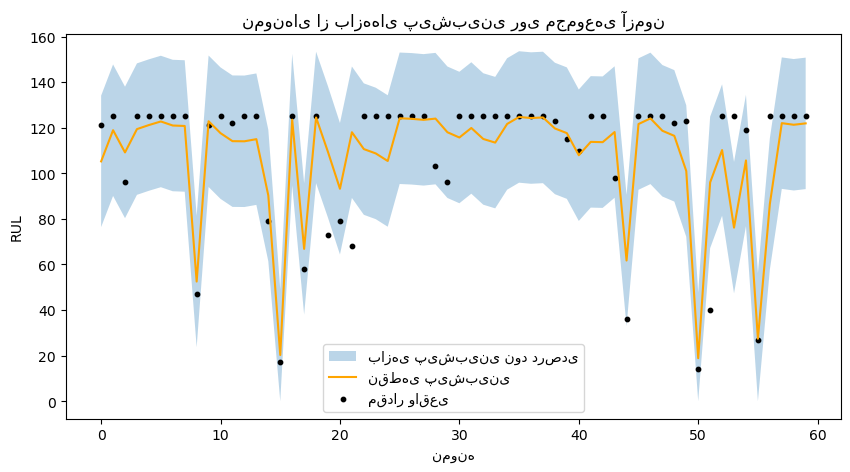

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))
sample_idx = np.random.RandomState(SEED).choice(len(test_preds_best), 60, replace=False)
sample_idx = np.sort(sample_idx)

ax.fill_between(
    range(len(sample_idx)), test_lower[sample_idx], test_upper[sample_idx],
    alpha=0.3, label="بازه‌ی پیش‌بینی نود درصدی"
)
ax.plot(range(len(sample_idx)), test_preds_best[sample_idx], color="orange", label="نقطه‌ی پیش‌بینی")
ax.scatter(range(len(sample_idx)), y_test_capped.values[sample_idx], color="black", s=10, label="مقدار واقعی")
ax.set_xlabel("نمونه")
ax.set_ylabel("RUL")
ax.set_title("نمونه‌ای از بازه‌های پیش‌بینی روی مجموعه‌ی آزمون")
ax.legend()
plt.show()

## گام هفت (ادامه) — حاشیه‌ی اطمینان آستانه‌ی ناهنجاری

فاصله‌ی امتیاز هر نمونه تا آستانه‌ی هشدار، به عنوان سنجه‌ای از قطعیت گزارش می‌شود.
از برچسب‌گذاری امتیاز خام به عنوان احتمال خودداری می‌شود.

In [59]:
def anomaly_confidence_margin(score_percentile, threshold_percentile=ALERT_PERCENTILE):
    """
    فاصله‌ی نسبی نمونه تا آستانه‌ی هشدار را برمی‌گرداند.
    مقدار مثبت بزرگ یعنی نمونه با اطمینان بالا در ناحیه‌ی ناهنجار است.
    مقدار منفی بزرگ یعنی نمونه با اطمینان بالا در ناحیه‌ی سالم است.
    مقدار نزدیک صفر یعنی نمونه نزدیک مرز است و عدم قطعیت بالاست.
    """
    return score_percentile - threshold_percentile


val_eval_anomaly["حاشیه_اطمینان"] = anomaly_confidence_margin(val_eval_anomaly["امتیاز_نهایی"])

near_boundary = val_eval_anomaly[val_eval_anomaly["حاشیه_اطمینان"].abs() < 10]
print(f"نسبت نمونه‌های نزدیک مرز تصمیم (حاشیه کمتر از ده درصدک): {len(near_boundary) / len(val_eval_anomaly):.3f}")

val_eval_anomaly[["engine_id", "cycle", "امتیاز_نهایی", "حاشیه_اطمینان"]].describe()

نسبت نمونه‌های نزدیک مرز تصمیم (حاشیه کمتر از ده درصدک): 0.197


,engine_id,cycle,امتیاز_نهایی,حاشیه_اطمینان
count,4070.000000,4070.000000,4070.000000,4070.000000
mean,45.337346,106.488698,50.012285,-39.987715
std,28.278657,65.659973,27.705538,27.705538
min,1.000000,1.000000,0.073710,-89.926290
25%,19.000000,51.000000,27.270680,-62.729320
50%,45.000000,102.000000,48.161343,-41.838657
75%,77.000000,154.000000,73.941441,-16.058559
max,91.000000,269.000000,99.844390,9.844390


## گام هشت — منطق تصمیم نهایی

توصیه از ترکیب کران پایین بازه‌ی RUL، احتمال خرابی کالیبره‌شده، و پایداری ناهنجاری ساخته می‌شود.
هر توصیه باید به قانون محرک آن قابل ردیابی باشد.

In [60]:
def maintenance_recommendation(
    rul_lower_bound, fail_prob_10, fail_prob_20, fail_prob_30,
    anomaly_percentile, anomaly_persistent, thresholds
):
    """
    ترکیب سه خروجی مدل در یک توصیه‌ی نگهداری قابل ردیابی.
    خروجی شامل برچسب، دلیل محرک، و سطح اطمینان است.
    """
    # --- قاعده‌ی توقف: کران پایین بحرانی یا احتمال نزدیک‌مدت اعتبارسنجی‌شده ---
    if rul_lower_bound <= thresholds["rul_critical"]:
        return {
            "توصیه": "STOP",
            "دلیل": f"کران پایین بازه‌ی RUL ({rul_lower_bound:.0f}) از آستانه‌ی بحرانی کمتر است",
        }
    if fail_prob_10 >= thresholds["prob_10_critical"]:
        return {
            "توصیه": "STOP",
            "دلیل": f"احتمال خرابی ظرف ده سیکل ({fail_prob_10:.2f}) از آستانه‌ی اعتبارسنجی‌شده بیشتر است",
        }

    # --- قاعده‌ی بازرسی: ریسک بالا، ناهنجاری پایدار، یا عدم قطعیت زیاد ---
    elevated_risk = fail_prob_20 >= thresholds["prob_20_elevated"] or fail_prob_30 >= thresholds["prob_30_elevated"]
    if elevated_risk or anomaly_persistent:
        return {
            "توصیه": "INSPECT",
            "دلیل": "ریسک بالا یا ناهنجاری پایدار شناسایی شد" if elevated_risk or anomaly_persistent else "",
        }

    # --- ادامه‌ی کار: همه‌ی سیگنال‌ها پایدار ---
    return {
        "توصیه": "CONTINUE",
        "دلیل": "کران پایین RUL مطمئن، احتمالات خرابی پایین، و امتیاز ناهنجاری پایدار",
    }


DECISION_THRESHOLDS = {
    "rul_critical": 15,
    "prob_10_critical": threshold_results_df.loc[threshold_results_df["افق"] == 10, "آستانه"].values[0],
    "prob_20_elevated": threshold_results_df.loc[threshold_results_df["افق"] == 20, "آستانه"].values[0],
    "prob_30_elevated": threshold_results_df.loc[threshold_results_df["افق"] == 30, "آستانه"].values[0],
}
print(DECISION_THRESHOLDS)

{'rul_critical': 15, 'prob_10_critical': 0.86, 'prob_20_elevated': 0.7000000000000001, 'prob_30_elevated': 0.59}


In [64]:
# --- آموزش نهایی مدل کلاس‌بندی برای هر افق (برای استفاده در تصمیم) ---
final_clf_models = {}
for h in HORIZONS:
    y_train_h = train_feat[f"fail_within_{h}"]
    model = make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
    )
    model.fit(X_train, y_train_h)
    final_clf_models[h] = model

# --- محاسبه‌ی امتیاز ناهنجاری برای val (قبلاً محاسبه شده در val_eval_anomaly) ---
sample_check = val_feat.sample(5, random_state=SEED).copy()

decision_records = []
for idx, row in sample_check.iterrows():
    x_row = row[FEATURE_COLS].to_frame().T

    rul_point = best_model.predict(x_row)[0]
    rul_lb = max(0, rul_point - conformal_margin)

    fail_probs = {h: final_clf_models[h].predict_proba(x_row)[0, 1] for h in HORIZONS}

    anomaly_row = val_eval_anomaly.loc[
        (val_eval_anomaly["engine_id"] == row["engine_id"]) & (val_eval_anomaly["cycle"] == row["cycle"])
    ]
    anomaly_pct = anomaly_row["امتیاز_نهایی"].values[0]
    anomaly_persistent = anomaly_row["هشدار_لحظه‌ای"].values[0] == 1 if "هشدار_لحظه‌ای" in anomaly_row else False

    decision = maintenance_recommendation(
        rul_lb, fail_probs[10], fail_probs[20], fail_probs[30],
        anomaly_pct, anomaly_persistent, DECISION_THRESHOLDS
    )

    decision_records.append({
        "engine_id": row["engine_id"], "cycle": row["cycle"],
        "RUL_واقعی": row["RUL"], "کران_پایین_RUL": rul_lb,
        "احتمال_۱۰": fail_probs[10], "احتمال_۲۰": fail_probs[20], "احتمال_۳۰": fail_probs[30],
        "درصدک_ناهنجاری": anomaly_pct, "توصیه": decision["توصیه"], "دلیل": decision["دلیل"],
    })

decision_df = pd.DataFrame(decision_records)
decision_df

,engine_id,cycle,RUL_واقعی,کران_پایین_RUL,احتمال_۱۰,احتمال_۲۰,احتمال_۳۰,درصدک_ناهنجاری,توصیه,دلیل
0,11.0,145.0,95.0,69.174256,2.787247e-11,0.000004,0.000310,9.819820,CONTINUE,کران پایین RUL مطمئن، احتمالات خرابی پایین، و ...
1,81.0,183.0,57.0,31.601881,1.467746e-04,0.132087,0.500250,66.961507,CONTINUE,کران پایین RUL مطمئن، احتمالات خرابی پایین، و ...
2,32.0,53.0,138.0,71.492829,1.896559e-06,0.005859,0.035618,26.199836,CONTINUE,کران پایین RUL مطمئن، احتمالات خرابی پایین، و ...
3,54.0,156.0,101.0,65.856844,3.308777e-10,0.000011,0.000678,41.981982,CONTINUE,کران پایین RUL مطمئن، احتمالات خرابی پایین، و ...
4,5.0,217.0,52.0,6.622950,2.803270e-06,0.006440,0.165860,84.078624,STOP,کران پایین بازه‌ی RUL (7) از آستانه‌ی بحرانی ک...


## ذخیره‌ی آرتیفکت‌ها برای داشبورد

تمام اجزای لازم برای بازتولید استنتاج نوت‌بوک، بدون نیاز به آموزش دوباره، ذخیره می‌شود.

In [65]:
import joblib

# --- مدل رگرسیون RUL ---
joblib.dump(best_model, f"{ARTIFACTS_DIR}/rul_model_{FD}.joblib")

# --- مدل‌های کلاس‌بندی افق خرابی ---
joblib.dump(final_clf_models, f"{ARTIFACTS_DIR}/classification_models_{FD}.joblib")

# --- مدل‌های تشخیص ناهنجاری و مقیاس‌گر مربوطه ---
anomaly_models = {
    "iso_forest": iso_forest,
    "lof": lof,
    "oc_svm": oc_svm,
    "scaler": anomaly_scaler,
}
joblib.dump(anomaly_models, f"{ARTIFACTS_DIR}/anomaly_models_{FD}.joblib")

print("مدل‌ها و مقیاس‌گرها ذخیره شدند.")

مدل‌ها و مقیاس‌گرها ذخیره شدند.


In [66]:
import json as _json

metadata = {
    "fd": FD,
    "seed": SEED,
    "window": WINDOW,
    "rul_cap": RUL_CAP,
    "feature_columns": FEATURE_COLS,
    "constant_sensors_removed": CONSTANT_SENSORS,
    "horizons": HORIZONS,
    "decision_thresholds": DECISION_THRESHOLDS,
    "conformal_margin": float(conformal_margin),
    "conformal_alpha": ALPHA,
    "anomaly_alert_percentile": ALERT_PERCENTILE,
    "anomaly_persistence_rule": {"m_alerts": M_ALERTS, "n_window": N_WINDOW},
    "anomaly_score_threshold_raw": float(alert_threshold),
    "last_training_run": pd.Timestamp.now().isoformat(),
    "model_version": "v1.0",
}

with open(f"{ARTIFACTS_DIR}/metadata_{FD}.json", "w", encoding="utf-8") as f:
    _json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"متادیتا ذخیره شد: {ARTIFACTS_DIR}/metadata_{FD}.json")
print(_json.dumps(metadata, indent=2, ensure_ascii=False)[:500])

متادیتا ذخیره شد: ../artifacts/metadata_FD001.json
{
  "fd": "FD001",
  "seed": 42,
  "window": 5,
  "rul_cap": 125,
  "feature_columns": [
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_20",
    "sensor_21",
    "sensor_2_roll_mean_w5",
    "sensor_3_roll_mean_w5",
    "sensor_4_roll_mean_w5",
    "sensor_6_roll_mean_w5",
    "sensor_7_roll_mean_w5",
    "sensor_8_roll_mean_w5",
    "sensor_9_roll_mean_w5",
  


In [67]:
# --- بارگذاری مجدد آرتیفکت‌ها برای اطمینان از صحت ذخیره‌سازی ---
reloaded_rul_model = joblib.load(f"{ARTIFACTS_DIR}/rul_model_{FD}.joblib")

test_row = X_val.iloc[[0]]
original_pred = best_model.predict(test_row)[0]
reloaded_pred = reloaded_rul_model.predict(test_row)[0]

assert np.isclose(original_pred, reloaded_pred), "عدم تطابق بین مدل اصلی و مدل بارگذاری‌شده!"
print(f"تست پاریتی موفق: پیش‌بینی اصلی {original_pred:.2f} == پیش‌بینی بارگذاری‌شده {reloaded_pred:.2f}")

تست پاریتی موفق: پیش‌بینی اصلی 123.10 == پیش‌بینی بارگذاری‌شده 123.10
